In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
%pip install scipy


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
cru_path = "/glade/work/kumar34/GSEI2070_DAT/cru_ts4.09.1901.2024.tmp.dat.nc"

ds = xr.open_dataset(cru_path, engine="netcdf4")
print(ds)

<xarray.Dataset> Size: 8GB
Dimensions:  (lon: 720, lat: 360, time: 1488)
Coordinates:
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) datetime64[ns] 12kB 1901-01-16 1901-02-15 ... 2024-12-16
Data variables:
    tmp      (time, lat, lon) float32 2GB ...
    stn      (time, lat, lon) float64 3GB ...
    mae      (time, lat, lon) float32 2GB ...
    maea     (time, lat, lon) float32 2GB ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.09 Mean Temperature
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2503051245. Data generated from:tmp.2503051121.dtb
    history:      Wed  5 Mar 13:28:04 GMT 2025 : User f098 : Program makegrid...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user

In [4]:
tmp = ds["tmp"]

In [5]:
auburn_lat = 32.61
auburn_lon = -85.48

In [6]:
tmp_ref = tmp.sel(time=slice("1951-01-01", "1980-12-31")).load()


In [7]:
monthly_clim = tmp_ref.groupby("time.month").mean(dim="time")
print("Monthly climatology shape:", monthly_clim.shape)

Monthly climatology shape: (12, 360, 720)


In [8]:
clim_auburn = monthly_clim.sel(lat=auburn_lat, lon=auburn_lon, method="nearest")

In [9]:
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

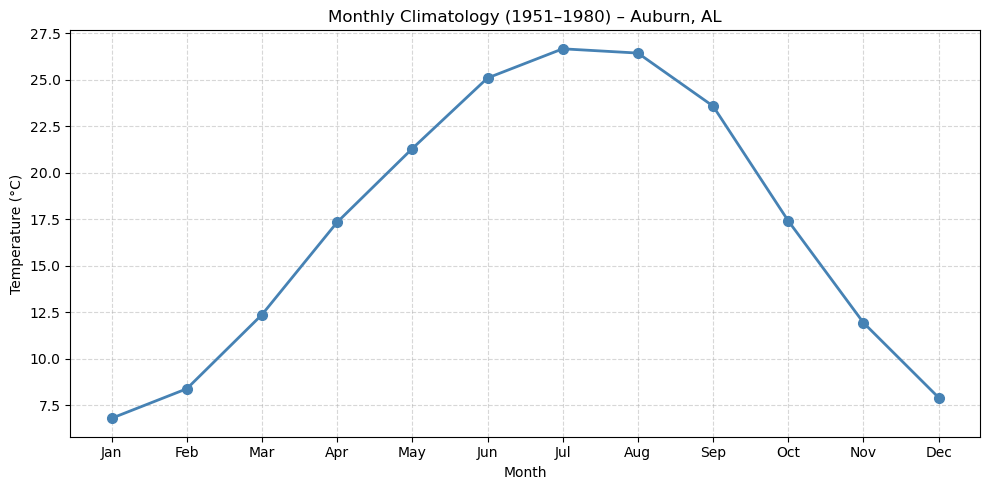

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 13), clim_auburn.values, marker="o", color="steelblue",
        linewidth=2, markersize=7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_xlabel("Month")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Monthly Climatology (1951–1980) – Auburn, AL")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Q2b_monthly_climatology_auburn.png", dpi=150)
plt.show()


In [11]:
monthly_anom = tmp.groupby("time.month") - monthly_clim
print("Monthly anomaly shape:", monthly_anom.shape)


Monthly anomaly shape: (1488, 360, 720)


In [12]:
annual_anom = monthly_anom.resample(time="1YE").mean(dim="time")

In [13]:
rolling_anom = annual_anom.rolling(time=5, center=True, min_periods=1).mean()


In [14]:
annual_auburn  = annual_anom.sel(lat=auburn_lat, lon=auburn_lon, method="nearest")
rolling_auburn = rolling_anom.sel(lat=auburn_lat, lon=auburn_lon, method="nearest")

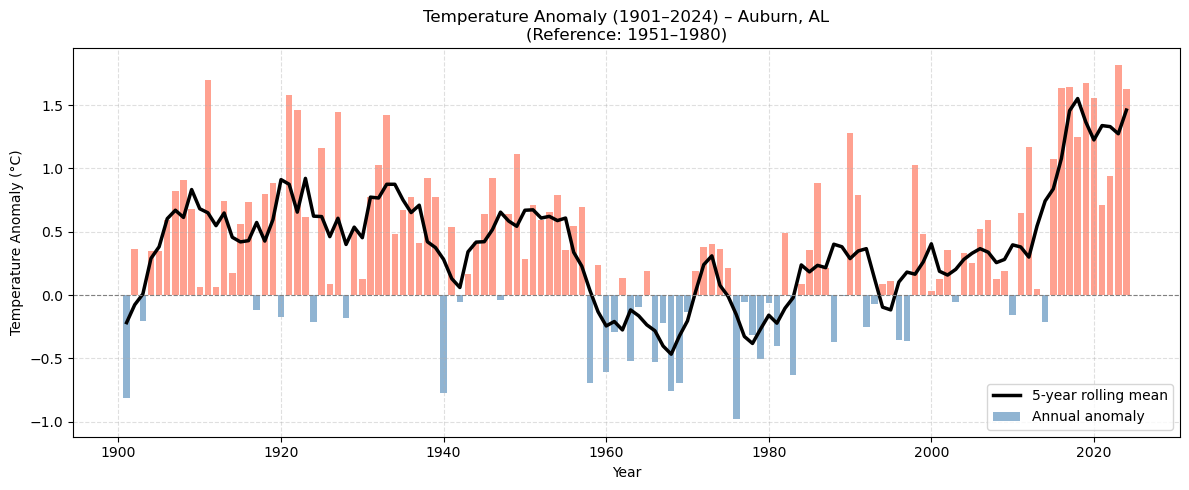

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(annual_auburn.time.dt.year, annual_auburn.values,
       color=np.where(annual_auburn.values >= 0, "tomato", "steelblue"),
       alpha=0.6, label="Annual anomaly")
ax.plot(rolling_auburn.time.dt.year, rolling_auburn.values,
        color="black", linewidth=2.5, label="5-year rolling mean")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature Anomaly (°C)")
ax.set_title("Temperature Anomaly (1901–2024) – Auburn, AL\n(Reference: 1951–1980)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("Q2e_anomaly_auburn.png", dpi=150)
plt.show()


In [16]:
weights = np.cos(np.deg2rad(annual_anom.lat))
weights.name = "weights"

In [17]:
global_annual  = annual_anom.weighted(weights).mean(dim=["lat", "lon"])
global_rolling = global_annual.rolling(time=5, center=True, min_periods=1).mean()

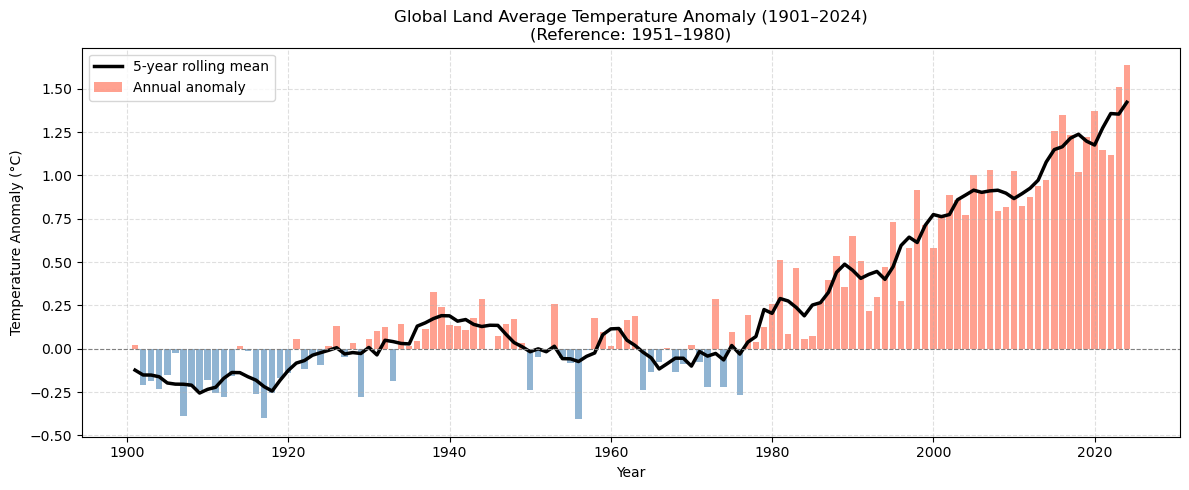

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(global_annual.time.dt.year, global_annual.values,
       color=np.where(global_annual.values >= 0, "tomato", "steelblue"),
       alpha=0.6, label="Annual anomaly")
ax.plot(global_rolling.time.dt.year, global_rolling.values,
        color="black", linewidth=2.5, label="5-year rolling mean")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature Anomaly (°C)")
ax.set_title("Global Land Average Temperature Anomaly (1901–2024)\n(Reference: 1951–1980)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("Q2f_anomaly_global.png", dpi=150)
plt.show()

In [19]:
cesm_base = "/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/month_1/TREFHT/"

In [20]:
giss_path = "/glade/work/kumar34/GSEI2070_DAT/GISS_surface_temp.nc"

In [21]:
members_orig = [
    "1001.001", "1001.002", "1001.003", "1001.004", "1001.005",
    "1001.006", "1001.007", "1001.008", "1001.009", "1001.010"
]

In [22]:
members_new = [
    "1301.011", "1301.012", "1301.013", "1301.014", "1301.015",
    "1301.016", "1301.017", "1301.018", "1301.019", "1301.020"
]

In [23]:
all_members = members_orig + members_new

In [24]:
def get_cesm_path(member):
    """
    CESM2-LE file naming convention:
    b.e21.BHISTsmbb.f09_g17.LE2-<member>.cam.h0.TREFHT.<start>-<end>.nc
    Historical ends 2015; SSP370 continues from 2015.
    Adjust glob/path as needed for your actual directory structure.
    """
    import glob
    pattern = f"{cesm_base}*LE2-{member}*.nc"
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files found for member {member} at {pattern}")
    return files

In [26]:
ref_start, ref_end = "1951", "1980"
ensemble_global  = []
ensemble_auburn  = []
 
print("Loading CESM2-LE ensemble members...")
for member in all_members:
    print(f"  Loading member: {member}")
    try:
        files = get_cesm_path(member)
        ds_m = xr.open_mfdataset(files, combine="by_coords")
        tref = ds_m["TREFHT"] - 273.15
        tref_ann = tref.resample(time="1YE").mean()
        tref_ref = tref_ann.sel(time=slice(ref_start, ref_end)).mean(dim="time")
        tref_anom = tref_ann - tref_ref
        w = np.cos(np.deg2rad(tref_anom.lat))
        w.name = "weights"
        global_ts = tref_anom.weighted(w).mean(dim=["lat", "lon"])
        auburn_ts = tref_anom.sel(lat=auburn_lat, lon=auburn_lon + 360,
                                  method="nearest")
        ensemble_global.append(global_ts)
        ensemble_auburn.append(auburn_ts)
    except Exception as e:
        print(f"    WARNING: Could not load member {member}: {e}")

Loading CESM2-LE ensemble members...
  Loading member: 1001.001
  Loading member: 1001.002
  Loading member: 1001.003
  Loading member: 1001.004
  Loading member: 1001.005
  Loading member: 1001.006
  Loading member: 1001.007
  Loading member: 1001.008
  Loading member: 1001.009
  Loading member: 1001.010
  Loading member: 1301.011
  Loading member: 1301.012
  Loading member: 1301.013
  Loading member: 1301.014
  Loading member: 1301.015
  Loading member: 1301.016
  Loading member: 1301.017
  Loading member: 1301.018
  Loading member: 1301.019
  Loading member: 1301.020


In [27]:
ens_global = xr.concat(ensemble_global, dim="member")
ens_auburn = xr.concat(ensemble_auburn, dim="member")

In [28]:
ens_global_mean = ens_global.mean(dim="member")
ens_global_std  = ens_global.std(dim="member")

In [29]:
ens_auburn_mean = ens_auburn.mean(dim="member")
ens_auburn_std  = ens_auburn.std(dim="member")

In [30]:
giss_path = "/glade/work/kumar34/GSEI2070_DAT/gistemp1200_GHCNv4_ERSSTv5.nc"
ds_giss = xr.open_dataset(giss_path)

In [31]:
print(ds_giss)
print(ds_giss.data_vars)

<xarray.Dataset> Size: 114MB
Dimensions:      (lat: 90, lon: 180, time: 1754, nv: 2)
Coordinates:
  * lat          (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time         (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2026-02-15
Dimensions without coordinates: nv
Data variables:
    time_bnds    (time, nv) datetime64[ns] 28kB ...
    tempanomaly  (time, lat, lon) float32 114MB ...
Attributes:
    title:        GISTEMP Surface Temperature Analysis
    institution:  NASA Goddard Institute for Space Studies
    source:       http://data.giss.nasa.gov/gistemp/
    Conventions:  CF-1.6
    history:      Created 2026-03-09 07:11:49 by SBBX_to_nc 2.0 - ILAND=1200,...
Data variables:
    time_bnds    (time, nv) datetime64[ns] 28kB ...
    tempanomaly  (time, lat, lon) float32 114MB ...


In [40]:
giss_raw = ds_giss["tempanomaly"]
print("Raw shape:", giss_raw.shape)

weights_giss = np.cos(np.deg2rad(ds_giss.lat))
weights_giss.name = "weights"
giss_ts = giss_raw.weighted(weights_giss).mean(dim=["lat", "lon"])
print("After spatial mean:", giss_ts.shape)

giss_ts = giss_ts.resample(time="1YE").mean()
years_giss = giss_ts.time.dt.year.values
years_global = ens_global_mean.time.dt.year.values
years_auburn = ens_auburn_mean.time.dt.year.values
print("Years:", years_giss[0], "–", years_giss[-1])

Raw shape: (1754, 90, 180)
After spatial mean: (1754,)
Years: 1880 – 2026


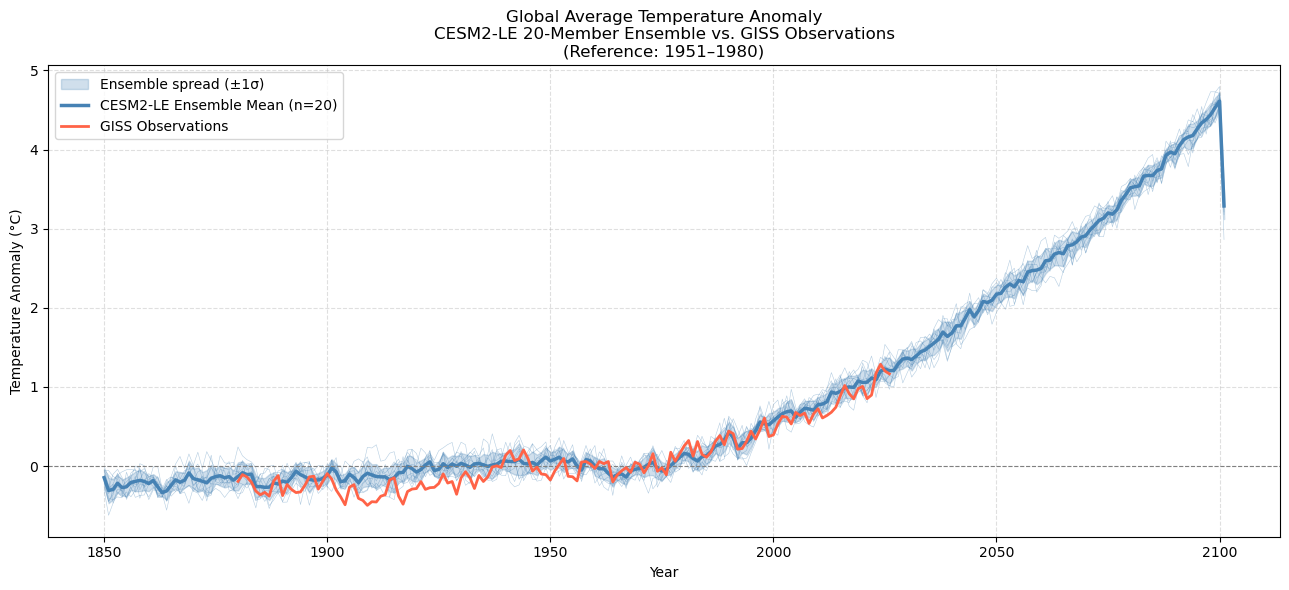

In [42]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.fill_between(years_global,
                ens_global_mean.values - ens_global_std.values,
                ens_global_mean.values + ens_global_std.values,
                alpha=0.25, color="steelblue", label="Ensemble spread (±1σ)")

for i in range(ens_global.sizes["member"]):
    ax.plot(years_global, ens_global.isel(member=i).values,
            color="steelblue", linewidth=0.4, alpha=0.4)

ax.plot(years_global, ens_global_mean.values,
        color="steelblue", linewidth=2.5, label="CESM2-LE Ensemble Mean (n=20)")

ax.plot(years_giss, giss_ts.values,
        color="tomato", linewidth=2, label="GISS Observations", zorder=5)
 
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature Anomaly (°C)")
ax.set_title("Global Average Temperature Anomaly\nCESM2-LE 20-Member Ensemble vs. GISS Observations\n(Reference: 1951–1980)")
ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("Q3c_global_ensemble_giss.png", dpi=150)
plt.show()

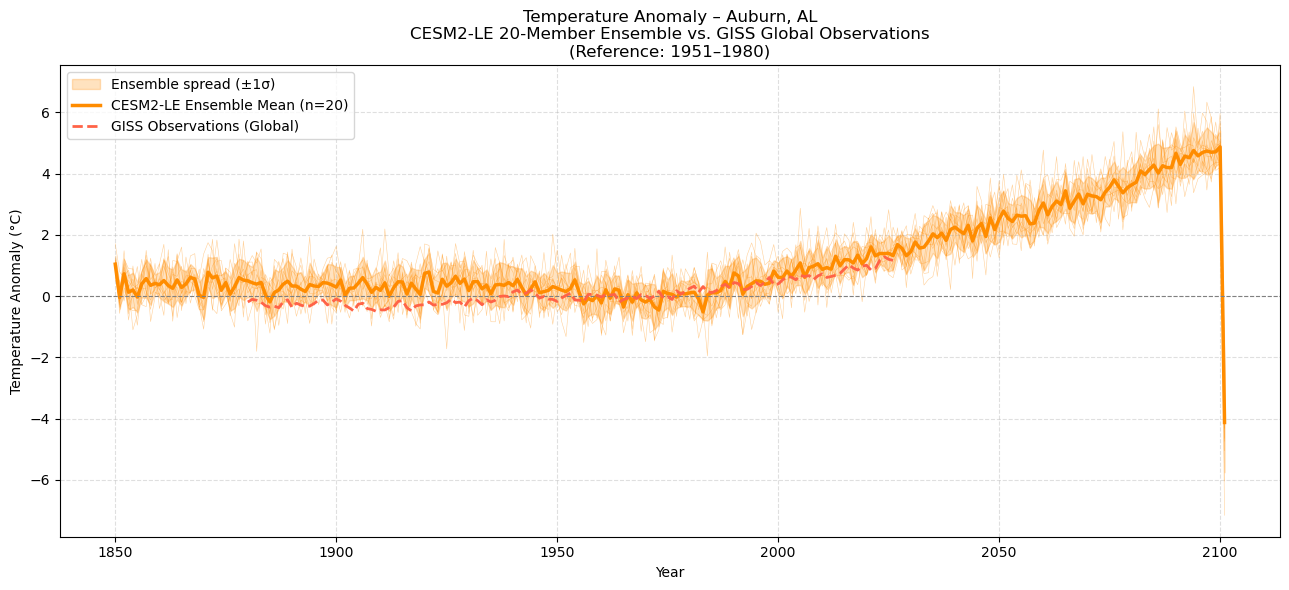

In [43]:
fig, ax = plt.subplots(figsize=(13, 6))
 
ax.fill_between(years_auburn,
                ens_auburn_mean.values - ens_auburn_std.values,
                ens_auburn_mean.values + ens_auburn_std.values,
                alpha=0.25, color="darkorange", label="Ensemble spread (±1σ)")
 
for i in range(ens_auburn.sizes["member"]):
    ax.plot(years_auburn, ens_auburn.isel(member=i).values,
            color="darkorange", linewidth=0.4, alpha=0.4)
 
ax.plot(years_auburn, ens_auburn_mean.values,
        color="darkorange", linewidth=2.5, label="CESM2-LE Ensemble Mean (n=20)")
 
ax.plot(years_giss, giss_ts.values,
        color="tomato", linewidth=2, linestyle="--",
        label="GISS Observations (Global)", zorder=5)
 
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature Anomaly (°C)")
ax.set_title("Temperature Anomaly – Auburn, AL\nCESM2-LE 20-Member Ensemble vs. GISS Global Observations\n(Reference: 1951–1980)")
ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("Q3e_auburn_ensemble_giss.png", dpi=150)
plt.show()

In [46]:
import os
os.chdir(os.path.expanduser("~/gsei2070_1_O-Harrah"))

In [47]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [51]:
!mkdir -p Assignment7
!cp ~/Q2b_monthly_climatology_auburn.png Assignment7/
!cp ~/Q2e_anomaly_auburn.png Assignment7/
!cp ~/Q2f_anomaly_global.png Assignment7/
!cp ~/Q2g_comparison.png Assignment7/
!cp ~/Q3c_global_ensemble_giss.png Assignment7/
!cp ~/Q3e_auburn_ensemble_giss.png Assignment7/

cp: cannot stat '/glade/u/home/harrah/Q2g_comparison.png': No such file or directory


In [52]:
!cp ~/u/home/harrah/assignment_7.ipynb Assignment7/

cp: cannot stat '/glade/u/home/harrah/Assignment_7.py': No such file or directory


In [49]:
!git add Assignment7/
!git commit -m "Add Assignment 7: CRU xarray analysis and CESM2-LE ensemble plots"
!git push origin main

[main c7ddabe] Add Assignment 7: CRU xarray analysis and CESM2-LE ensemble plots
 Committer: Trey O'Harrah <harrah@dec1515.hsn.de.hpc.ucar.edu>
Your name and email address were configured automatically based
on your username and hostname. Please check that they are accurate.
You can suppress this message by setting them explicitly. Run the
following command and follow the instructions in your editor to edit
your configuration file:

    git config --global --edit

After doing this, you may fix the identity used for this commit with:

    git commit --amend --reset-author

 5 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 Assignment7/Q2b_monthly_climatology_auburn.png
 create mode 100644 Assignment7/Q2e_anomaly_auburn.png
 create mode 100644 Assignment7/Q2f_anomaly_global.png
 create mode 100644 Assignment7/Q3c_global_ensemble_giss.png
 create mode 100644 Assignment7/Q3e_auburn_ensemble_giss.png
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta 

In [50]:
!git log --oneline -3

c7ddabe (HEAD -> main, origin/main) Add Assignment 7: CRU xarray analysis and CESM2-LE ensemble plots
fb561e0 q2_gistemp_analysis.py
fdf0dfe Add CRU analysis script
